In [100]:
import pandas as pd
from sklearn.feature_selection import mutual_info_regression

df = pd.read_csv('../data/AmesHousing.csv')
df.head()
y = df['SalePrice']
df = df.drop([f for f in df.columns if df[f].isna().sum() > 0], axis=1)
#df.drop(['SalePrice', 'Neighborhood'], axis=1, inplace=True)


In [130]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def make_mi_scores(X, y):
    X = X.copy()

    for colname in X.select_dtypes(include=['object', 'category', 'str']):
        X[colname], _ = X[colname].factorize()
    
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y,random_state=42)
    mi_scores = pd.Series(mi_scores, name="MI_Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

def plot_mi_scores(scores):

    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores.values))
    ticks = list(scores.index)

    
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")
    #plt.autoscale(enable=True, axis='y', tight=None)
    plt.tight_layout()




X = df.copy()
y = X.pop('SalePrice')

mi_scores = make_mi_scores(X, y)
# mi_scores




In [ ]:
features = ["Year Built", "Mo Sold", "Screen Porch"]
df.melt(id_vars="SalePrice", value_vars=features)

sns.relplot(
    x="value", y="SalePrice", col="variable", data=df.melt(id_vars="SalePrice", value_vars=features),
    facet_kws=dict(sharex=False)
)


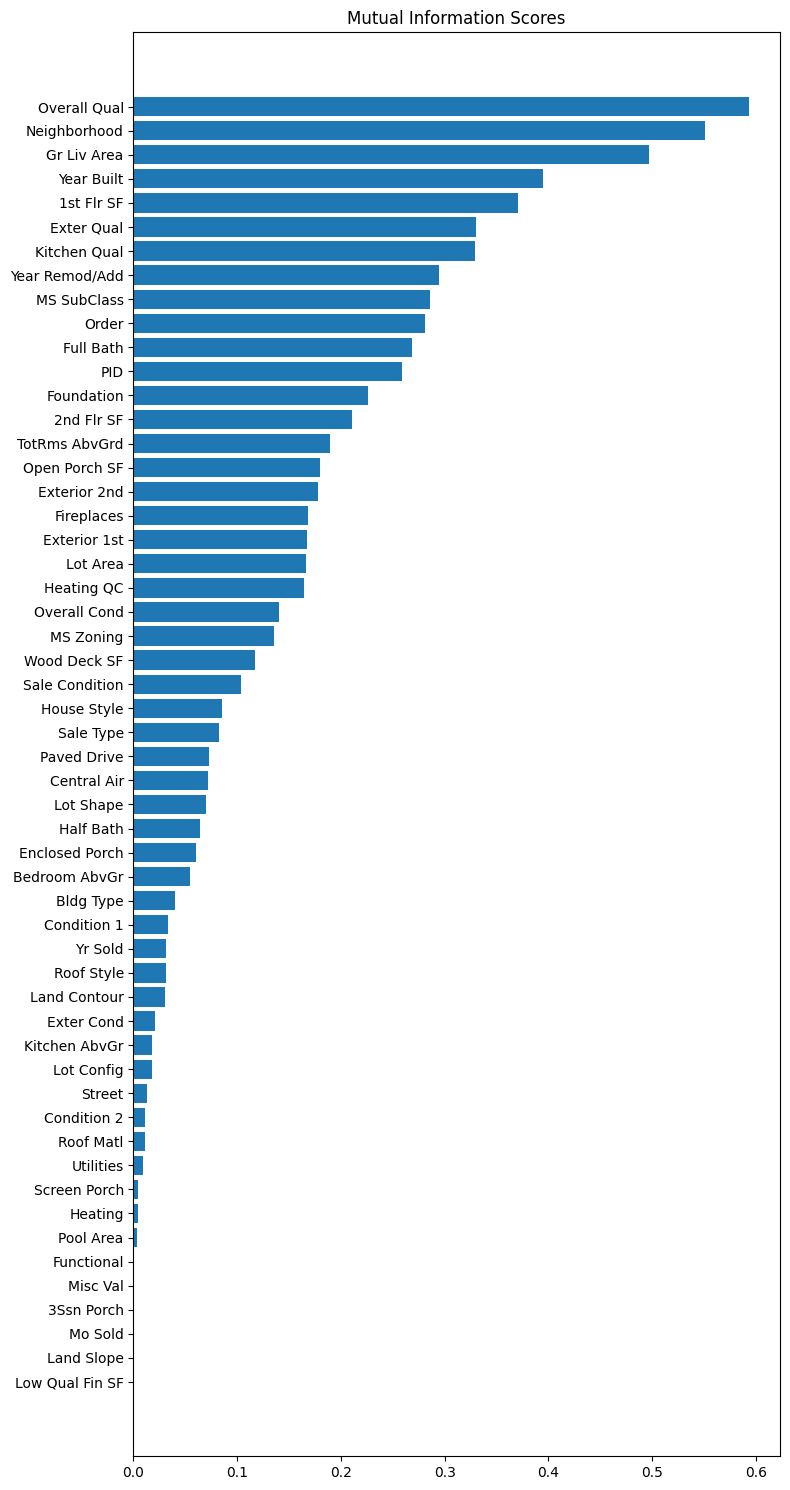

In [146]:
plt.figure(dpi=100, figsize=(8, 15))
plot_mi_scores(mi_scores)

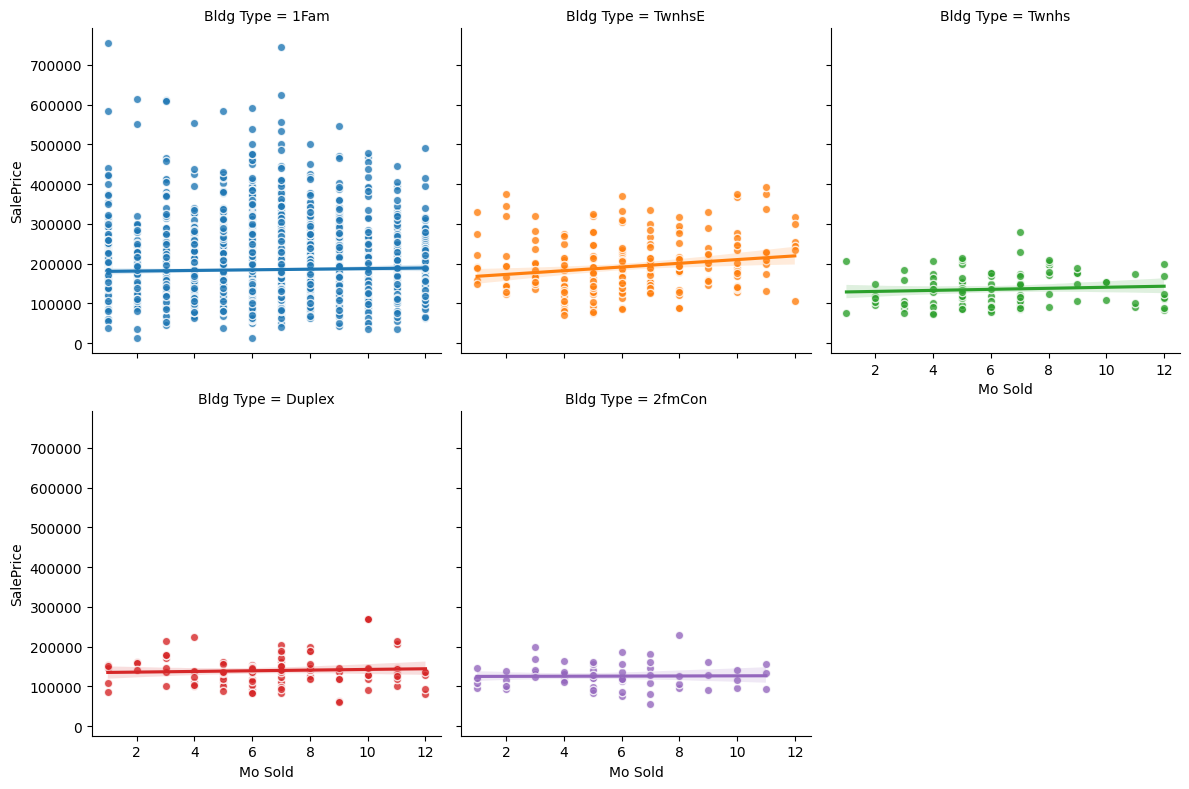

In [156]:
# sns.catplot(x='Bldg Type', y="SalePrice", data=df, kind='boxen')

# sns.lmplot(x="Gr Liv Area", y="SalePrice", hue="Bldg Type",col="Bldg Type", data=df,
#            scatter_kws={"edgecolor": 'w'}, col_wrap=3, height=4)

sns.lmplot(x="Mo Sold", y="SalePrice", data=df, hue="Bldg Type", col="Bldg Type",\
            col_wrap=3, height=4, scatter_kws={"edgecolor":'w'})